# Homework — Stage 08 EDA

Fill in the marked TODOs. This notebook generates synthetic data so you can focus on the EDA flow. Replace with your dataset when ready.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install --upgrade pandas   # if an older pandas is already installed

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


## 1) First look

In [2]:
df.info(), df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[us]
 1   region        160 non-null    str           
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int64         
 5   spend         157 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 8.3 KB


(None,
 date            0
 region          0
 age             0
 income          5
 transactions    0
 spend           3
 dtype: int64)

## 2) Numeric profile

In [3]:
desc = df[['age','income','transactions','spend']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.018750,8.458676,22.00,34.70,40.15,44.925,61.10,0.069538,-0.080125
income,155.0,41983.866323,13262.457038,17928.80,32471.53,39332.52,49697.690,87052.40,0.993336,0.918722
transactions,160.0,3.237500,2.585610,0.00,2.00,3.00,4.000,20.00,3.466078,19.984802
spend,157.0,117.291592,51.768645,0.54,77.25,119.32,153.340,280.05,0.130860,-0.084917


## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs
its own look: how many distinct values it has, how lopsided the split is, and whether one
category dominates so heavily that it will be useless as a feature.

`region` is the categorical column in this synthetic set. Your own dataset may have
several — profile all of them.


--- region ---
region
West     47
East     42
South    36
North    35
Name: count, dtype: int64
region
West     0.29375
East     0.26250
South    0.22500
North    0.21875
Name: proportion, dtype: float64


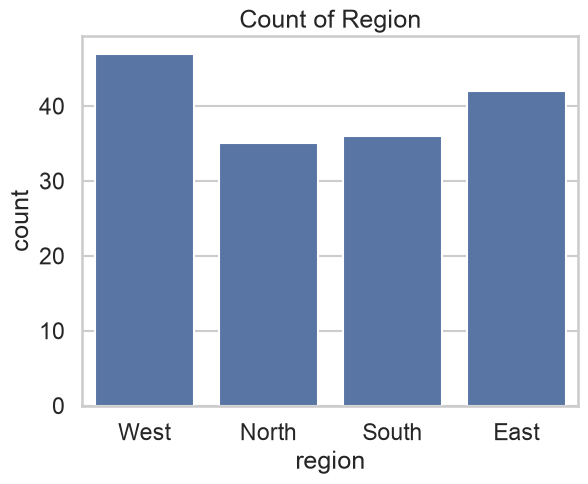

In [6]:
# TODO: value counts for every non-numeric column.
#   Hint: df.select_dtypes(exclude='number').columns gives you the list.
#   Print counts AND proportions — a raw count hides how lopsided a split is.

# TODO: plot one of them with sns.countplot (the lecture uses this in section 3).

cat_cols = df.select_dtypes(exclude="number").columns.drop("date")

for c in cat_cols:
    print(f"\n--- {c} ---")
    print(df[c].value_counts(dropna=False))
    print(df[c].value_counts(normalize=True, dropna=False))

sns.countplot(data=df, x="region")
plt.title("Count of Region")
plt.show()

## 3) Distributions — two worked examples below; add at least one more

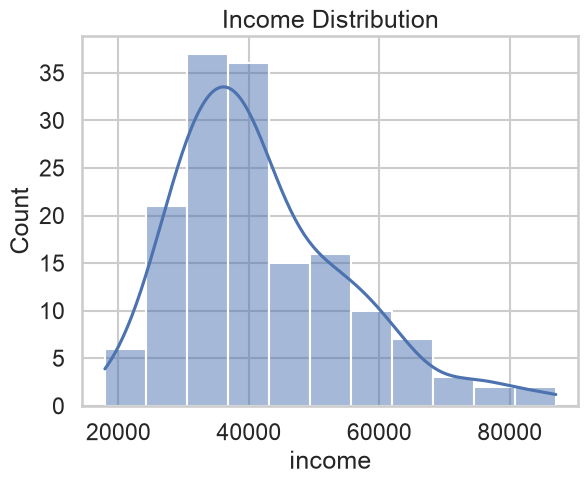

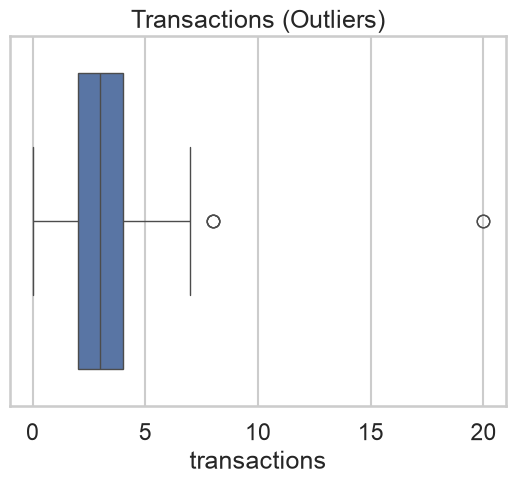

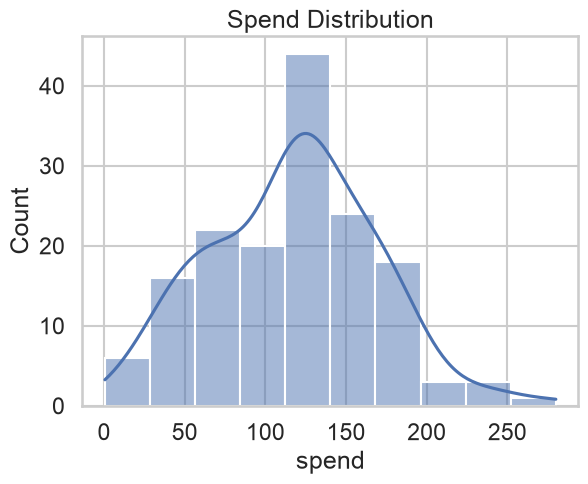

In [7]:
# Example 1 of 2 — histogram + KDE. Keep it, or swap in a column of your own.
sns.histplot(df['income'], kde=True)
plt.title('Income Distribution')
plt.show()

# Example 2 of 2 — boxplot, to expose outliers.
#
# TODO: add ONE more distribution below, on a column of your choosing (3 are required).
sns.boxplot(x=df['transactions'])
plt.title('Transactions (Outliers)')
plt.show()

sns.histplot(df["spend"], kde=True)
plt.title("Spend Distribution")
plt.show()


## 4) Relationships — both are worked below; swap in your own columns

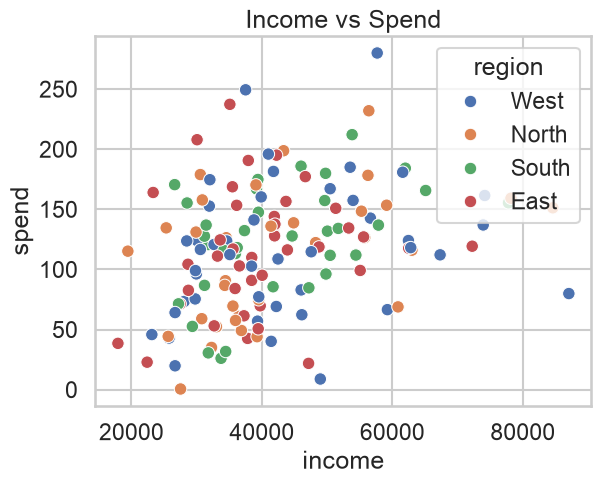

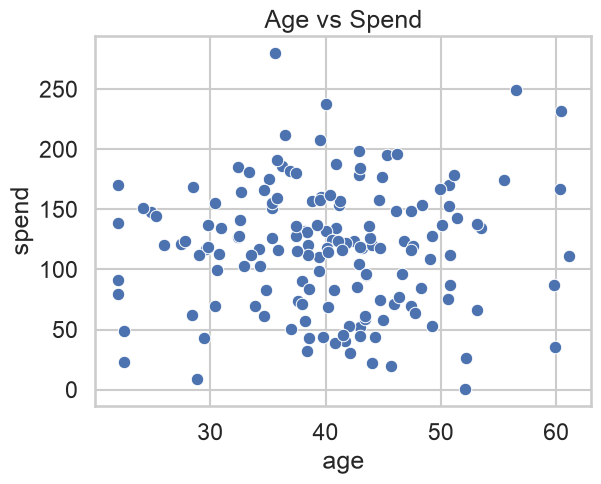

In [8]:
sns.scatterplot(data=df, x='income', y='spend', hue='region')
plt.title('Income vs Spend')
plt.show()

sns.scatterplot(data=df, x='age', y='spend')
plt.title('Age vs Spend')
plt.show()

## 4b) Over time

Nothing above uses the `date` column — and a dataset with a date almost always has
something to say along it: a trend, a seasonal cycle, or a level shift where behaviour
changed.

This is not optional detail. Stage 09 builds lag and rolling features on exactly this
axis, and stage 10b splits the data on it. What you find here decides what those stages
can do — and if the rows are out of order, or there are gaps in the dates, both of
those stages produce nonsense without telling you.

In [9]:
# TODO: plot at least one variable over time.
#   Hint: sort by `date` first, then set it as the index. Order matters — a rolling
#   mean computed over out-of-order rows is meaningless.
ts_df = df.copy()
ts_df['date'] = pd.to_datetime(ts_df['date'])
ts_df = ts_df.sort_values('date')
ts_df.set_index('date', inplace=True)

In [10]:
# TODO: check for GAPS in the dates too. A rolling window that spans a missing week is
#   not the window you think it is.
full_dates = pd.date_range(
    start=ts_df.index.min(),
    end=ts_df.index.max(),
    freq='D'
)

missing_dates = full_dates.difference(ts_df.index)

print("Number of missing dates:", len(missing_dates))
print("Missing dates:", missing_dates)

Number of missing dates: 0
Missing dates: DatetimeIndex([], dtype='datetime64[us]', freq='D')


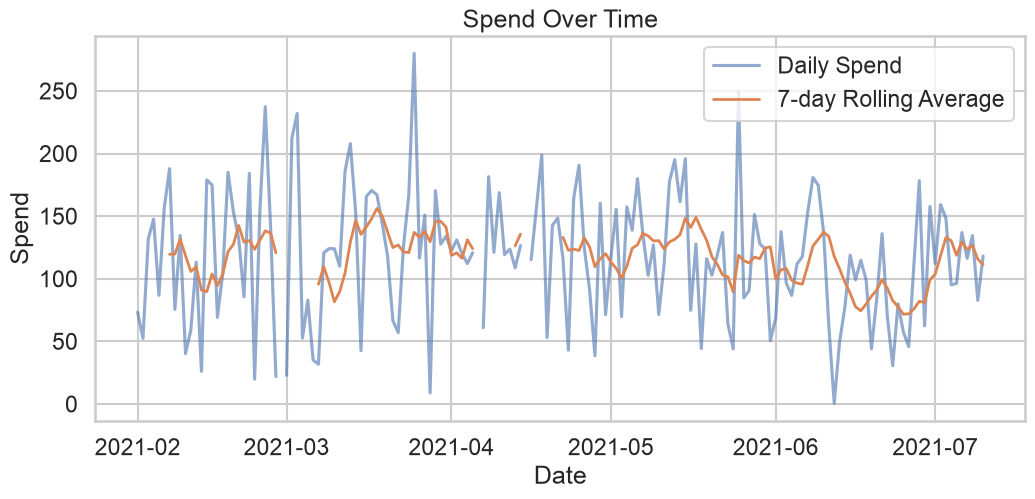

In [11]:
# Plot one variable over time
plt.figure(figsize=(12, 5))
plt.plot(ts_df.index, ts_df['spend'], alpha=0.6, label='Daily Spend')
plt.plot(
    ts_df['spend'].rolling(7).mean(),
    linewidth=2,
    label='7-day Rolling Average'
)

plt.title('Spend Over Time')
plt.xlabel('Date')
plt.ylabel('Spend')
plt.legend()
plt.show()

TODO: then say what you see in a markdown cell: trend, seasonality, a level shift, or genuinely nothing. 'Nothing' is a real finding if you can show it.

The daily spend fluctuates substantially, but the 7-day rolling average remains relatively stable over time. There is no clear long-term upward or downward trend, no obvious seasonality, and no persistent level shift. Most of the variation appears to be short-term fluctuation.

## 5) (Optional) Correlation matrix

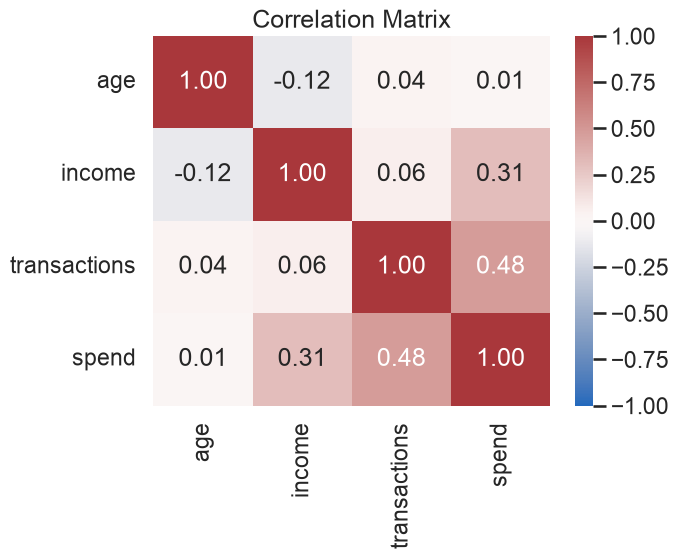

,age,income,transactions,spend
age,1.000000,-0.123160,0.037754,0.008174
income,-0.123160,1.000000,0.063573,0.307307
transactions,0.037754,0.063573,1.000000,0.480685
spend,0.008174,0.307307,0.480685,1.000000


In [12]:
corr = df[['age','income','transactions','spend']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr

## 5b) Your reusable helper — `src/eda.py`

The lecture built `eda_summary(df)` in its section 8. Copy it into `src/eda.py`, import
it here, and call it.

Stage 06 gave your project `src/cleaning.py` and stage 09 will want `src/features.py`.
This is stage 08's contribution to the same set, and the point is that your project keeps
ONE profiling function instead of ten pasted copies of it.

In [13]:
# TODO: create src/eda.py, paste the lecture's eda_summary() into it, then:
from src.eda import eda_summary
eda_summary(df)

{'shape': (160, 6),
 'dtypes': {'date': dtype('<M8[us]'),
  'region': <StringDtype(na_value=nan)>,
  'age': dtype('float64'),
  'income': dtype('float64'),
  'transactions': dtype('int64'),
  'spend': dtype('float64')},
 'missing': {'date': 0,
  'region': 0,
  'age': 0,
  'income': 5,
  'transactions': 0,
  'spend': 3},
 'numeric_profile':               count          mean           std       min       25%       50%  \
 age           160.0     40.018750      8.458676     22.00     34.70     40.15   
 income        155.0  41983.866323  13262.457038  17928.80  32471.53  39332.52   
 transactions  160.0      3.237500      2.585610      0.00      2.00      3.00   
 spend         157.0    117.291592     51.768645      0.54     77.25    119.32   
 
                     75%       max      skew   kurtosis  
 age              44.925     61.10  0.069538  -0.080125  
 income        49697.690  87052.40  0.993336   0.918722  
 transactions      4.000     20.00  3.466078  19.984802  
 spend         

In [14]:
# TODO (stretch): have it flag columns that need attention before stage 09 — high
#   missingness, near-zero variance, or one category dominating.
def flag_columns(df):
    flags = {}

    # High missingness
    for c in df.columns:
        missing_rate = df[c].isna().mean()
        if missing_rate > 0.3:
            flags[c] = flags.get(c, []) + ["high missingness"]

    # Near-zero variance for numeric columns
    for c in df.select_dtypes(include="number").columns:
        if df[c].nunique() <= 1:
            flags[c] = flags.get(c, []) + ["near-zero variance"]

    # Dominant category for categorical columns
    for c in df.select_dtypes(exclude="number").columns:
        top_share = df[c].value_counts(normalize=True, dropna=False).max()
        if top_share > 0.9:
            flags[c] = flags.get(c, []) + ["one category dominates"]

    return flags

In [15]:
flag_columns(df)

{}

## 6) Insights & Assumptions (write your commentary)
- TODO: Top 3 insights
- TODO: Assumptions & risks
- TODO: Next steps before modeling (cleaning & features)

### Top 3 insights
- `income` is moderately right-skewed, while `transactions` is strongly right-skewed and contains clear outliers.
- `spend` has positive relationships with both `income` and `transactions`, especially with `transactions`.
- `spend` varies considerably from day to day, but its 7-day rolling average is fairly stable, with no obvious trend, seasonality, or level shift.

### Assumptions & risks
- Missing values in `income` and `spend` need to be handled before modeling.
- The extreme transaction values may be real rare events or data-quality issues, so they should be investigated before removal.
- Because the dataset is small and synthetic, the observed patterns may not generalize well.

### Next steps before modeling
- Impute or otherwise handle missing values.
- Review and possibly cap/winsorize transaction outliers.
- Consider log transforms for skewed variables and create additional features such as interaction, lag, or rolling features.